# Project 1: From Raw Health Data to Reliable Insights

## A Foundational Health Data Science Project

**Project Type:** Exploratory Health Data Analysis  
**Health Focus:** Community Health Screening Data

# ANALYTICAL WORKFLOW

The project will follow this pipeline:


Research Question


       ↓

Data Acquisition

       ↓

Data Dictionary

       ↓

Data Inspection
 
       ↓

Data Quality Assessment

       ↓

Data Cleaning

       ↓

Descriptive Statistics

       ↓

Univariate Analysis

       ↓

Bivariate Analysis

 
       ↓

Grouped Analysis

       ↓

Feature Engineering
 
       ↓

Statistical Relationships
 
       ↓

Interpretation

       ↓

Limitations

   
       ↓
Final Findings

### Research Question

What patterns and relationships can be identified in the health characteristics of the screening participants, and what factors appear to be associated with differences in measured health outcomes?

**Sub-question 1 — Data Structure**
What does the dataset contain, and is it structured appropriately for analysis?

**Sub-question 2 — Distribution**
How are the major health measurements distributed?

**Sub-question 3 — Group Differences**
Do health measurements differ descriptively across relevant demographic or geographic groups?

**Sub-question 4 — Relationships**
Are variables such as age, blood pressure, and glucose associated with one another?

**Sub-question 5 — Data Quality**
Are missing values, unusual observations, or measurement issues likely to affect the findings?

**Sub-question 6 — Interpretation**
What can reasonably be concluded from the observed patterns, and what remains uncertain?

# THE PROBLEM

Health organizations collect large amounts of data, but having data does not automatically produce useful information.

A dataset may contain hundreds or thousands of measurements, yet before any meaningful conclusion can be made, a data scientist must determine:

- What does each observation represent?
- What variables were measured?
- Are the measurements complete?
- Are there errors?
- How are the variables distributed?
- Are there unusual observations?
- Do different groups appear different?
- Are variables associated with one another?
- What patterns are supported by the data?
- What conclusions cannot be supported?

This project investigates these questions systematically.

## STAGE A — DATA ACQUISITION ##

**Objective**
Load the dataset into Python and establish exactly what data are available.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [116]:
df=pd.read_csv("PARTICIPANT DATA.csv")

## STAGE B — DATA INSPECTION ##


In [117]:
df.head()

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
0,1,Participant001,31,M,136.0,132,90,14-Sep-26,Echolab
1,2,Participant002,40,M,80.0,133,85,14-Sep-26,Echolab
2,3,Participant003,49,F,89.0,96,72,14-Sep-26,Echolab
3,4,Participant004,49,F,97.0,114,82,14-Sep-26,Echolab
4,5,Participant005,37,M,79.0,111,68,12-Sep-26,Echolab


In [118]:
df.shape

(50, 9)

In [119]:
df.columns

Index(['S/N', 'Participant Name', 'Age', 'Sex', 'FBS/RBS (mg/dL)',
       'Systolic (mmHg)', 'Diastolic (mmHg)', 'Date', 'Location'],
      dtype='object')

In [120]:
df.info

<bound method DataFrame.info of     S/N Participant Name Age Sex  FBS/RBS (mg/dL)  Systolic (mmHg)  \
0     1   Participant001  31   M            136.0              132   
1     2   Participant002  40   M             80.0              133   
2     3   Participant003  49   F             89.0               96   
3     4   Participant004  49   F             97.0              114   
4     5   Participant005  37   M             79.0              111   
5     6   Participant006  25   F             81.0              139   
6     7   Participant007  32   M             85.2              179   
7     8   Participant008  35   F             90.2              134   
8     9   Participant009  35   M            104.6              114   
9    10   Participant010  Ad   M            158.4              126   
10   11   Participant011  28   F             93.6              101   
11   12   Participant012  36   F             90.0              128   
12   13   Participant013  26   F             72.0         

In [121]:
df=df.sort_values("Date")

In [122]:
df.dtypes

S/N                   int64
Participant Name     object
Age                  object
Sex                  object
FBS/RBS (mg/dL)     float64
Systolic (mmHg)       int64
Diastolic (mmHg)      int64
Date                 object
Location             object
dtype: object

In [123]:
df.isnull().sum()

S/N                 0
Participant Name    0
Age                 0
Sex                 0
FBS/RBS (mg/dL)     0
Systolic (mmHg)     0
Diastolic (mmHg)    0
Date                0
Location            0
dtype: int64

**Numerical Variable Summary**

In [124]:
df.describe()

,S/N,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg)
count,50.00000,50.00000,50.000000,50.000000
mean,25.50000,97.68800,119.780000,77.320000
std,14.57738,19.95513,15.749687,9.036073
min,1.00000,72.00000,94.000000,56.000000
25%,13.25000,84.30000,111.000000,70.000000
50%,25.50000,91.40000,119.000000,75.000000
75%,37.75000,102.45000,128.750000,85.000000
max,50.00000,167.00000,179.000000,98.000000


In [125]:
df.describe(include="object")

,Participant Name,Age,Sex,Date,Location
count,50,50,50,50,50
unique,50,25,2,4,3
top,Participant016,40,F,14-Sep-26,Echolab
freq,1,6,29,21,30


In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
(df=="").sum()

S/N                 0
Participant Name    0
Age                 0
Sex                 0
FBS/RBS (mg/dL)     0
Systolic (mmHg)     0
Diastolic (mmHg)    0
Date                0
Location            0
dtype: int64

**Unique Values**

Inspect the unique values of categorical variables to identify unexpected categories, inconsistent spelling, or other data-entry issues.

In [128]:
df.nunique()

S/N                 50
Participant Name    50
Age                 25
Sex                  2
FBS/RBS (mg/dL)     40
Systolic (mmHg)     32
Diastolic (mmHg)    25
Date                 4
Location             3
dtype: int64

In [129]:
df["Sex"].unique()

array(['F', 'M'], dtype=object)

In [130]:
df["Location"].unique()

array(['Echolab', 'DDPA Estate', 'Lifestream'], dtype=object)

**Category Frequencies**

Examine the number of observations in each category.

In [131]:
df["Sex"].value_counts()

Sex
F    29
M    21
Name: count, dtype: int64

In [132]:
df["Location"].value_counts()

Location
Echolab        30
DDPA Estate    16
Lifestream      4
Name: count, dtype: int64

# DATA INSPECTION REPORT

The dataset contains **50 observations**, with each observation representing a participant included in the community health screening exercise.One column, S/N, serves only as a serial numbering field and is not an analytical variable. Therefore, the dataset contains **8 analytical variables** relevant to the analysis.

The dataset contains both numerical and categorical variables. The numerical variables include the recorded health measurements, such as **random blood glucose (RBS), systolic blood pressure, diastolic blood pressure and age**. **Sex** and **Location** are categorical variables because they describe participant groups rather than numerical measurements.

The missing-value assessment showed **no missing values** in the dataset. The duplicate-record check also identified **no duplicate records**. Therefore, all 50 observations were retained for subsequent analysis.

The data types were inspected to determine whether the variables were stored appropriately for analysis. The quantitative health measurements are expected to be represented as numerical data types, while categorical variables such as Sex and Location are represented as categorical/text data. The S/N column serves only as a serial numbering field and does not form part of the analytical variables.

No data-type conversions were performed at this stage because the variables are already structured in a form suitable for the planned analysis. The dataset is therefore sufficiently structured to proceed to the next stage, where its data quality and the plausibility of the recorded measurements will be assessed.

# Sub-question 1 — Data Structure What does the dataset contain, and is it structured appropriately for analysis?

**Answer**

The data inspection establishes that the dataset contains 50 observations and 8 analytical variables. The variables include numerical health measurements and categorical variables such as Sex and Location. No missing values or duplicate records were identified, and the variables are appropriately structured for the planned analysis.

Therefore, **Sub-question 1 has been addressed:** the dataset contains the required participant and health-measurement information and is sufficiently structured to proceed with further analysis.

## DATA QUALITY AUDIT ##

This stage evaluates the quality and plausibility of the recorded health measurements. Unlike the initial data inspection, which focused on the structure of the dataset, this stage examines whether numerical observations fall within plausible ranges and whether unusual observations require further investigation.

Extreme values will not be automatically removed. Each unusual observation will be considered in the context of possible measurement variation, participant characteristics, and potential data-entry or measurement errors.

## Numerical Range Checks

For each major numerical health variable, examine its descriptive statistics to identify values that may require further investigation.

In [133]:
df["Systolic (mmHg)"].describe()

count     50.000000
mean     119.780000
std       15.749687
min       94.000000
25%      111.000000
50%      119.000000
75%      128.750000
max      179.000000
Name: Systolic (mmHg), dtype: float64

In [134]:
df["Diastolic (mmHg)"].describe()

count    50.000000
mean     77.320000
std       9.036073
min      56.000000
25%      70.000000
50%      75.000000
75%      85.000000
max      98.000000
Name: Diastolic (mmHg), dtype: float64

In [135]:
df["FBS/RBS (mg/dL)"].describe()

count     50.00000
mean      97.68800
std       19.95513
min       72.00000
25%       84.30000
50%       91.40000
75%      102.45000
max      167.00000
Name: FBS/RBS (mg/dL), dtype: float64

In [136]:
df["Age"].describe()

count     50
unique    25
top       40
freq       6
Name: Age, dtype: object

The audit did not provide a basis for automatically removing extreme observations, as unusual health measurements may represent genuine participant measurements. The Age variable, however, contains three entry recorded as "Ad", indicating an adult participant whose exact age was not provided. This is not treated as a data-entry error, but it means that the Age variable requires appropriate handling before numerical age-based analysis.

Overall, the audit identified a small data-format limitation in the Age variable while preserving the original recorded information. No observations were removed solely because they were unusually high or low.

Therefore, Sub-question 5 has been partially addressed at this stage. The identified data-quality considerations will be taken into account in subsequent analysis and interpretation.

# OUTLIER PRINCIPLE

An unusual observation is not automatically a mistake.

A very high or low measurement could represent:

- genuine biological variation,
- a participant requiring clinical attention,
- measurement error,
- data-entry error, or
- equipment-related problems.

Therefore, unusual observations will be investigated before any decision is made about their treatment.

No observation will be removed solely because it is extreme. Any removal or modification must be supported by evidence and documented.

In [137]:
df.nlargest(10, "Systolic (mmHg)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
6,7,Participant007,32,M,85.2,179,87,12-Sep-26,Echolab
47,48,Participant048,Ad,M,91.0,153,98,15-Sep-26,Lifestream
35,36,Participant036,42,M,75.0,140,93,14-Sep-26,DDPA Estate
5,6,Participant006,25,F,81.0,139,85,12-Sep-26,Echolab
38,39,Participant039,30,M,72.0,139,67,14-Sep-26,DDPA Estate
7,8,Participant008,35,F,90.2,134,87,12-Sep-26,Echolab
23,24,Participant024,45,F,97.9,134,88,14-Sep-26,Echolab
34,35,Participant035,30,M,83.0,133,87,13-Sep-26,DDPA Estate
1,2,Participant002,40,M,80.0,133,85,14-Sep-26,Echolab
31,32,Participant032,40,M,116.0,132,88,13-Sep-26,DDPA Estate


In [138]:
df.nsmallest(10, "Systolic (mmHg)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
15,16,Participant016,40,F,90.0,94,74,12-Sep-26,Echolab
2,3,Participant003,49,F,89.0,96,72,14-Sep-26,Echolab
48,49,Participant049,29,F,77.0,98,56,15-Sep-26,Lifestream
18,19,Participant019,43,F,90.2,100,70,12-Sep-26,Echolab
28,29,Participant029,40,F,89.8,101,70,12-Sep-26,Echolab
42,43,Participant043,21,F,96.2,101,67,13-Sep-26,DDPA Estate
43,44,Participant044,20,F,100.0,101,82,14-Sep-26,DDPA Estate
10,11,Participant011,28,F,93.6,101,72,14-Sep-26,Echolab
27,28,Participant028,47,F,75.6,102,77,12-Sep-26,Echolab
33,34,Participant034,26,F,112.0,105,70,13-Sep-26,DDPA Estate


In [139]:
df.nlargest(10, "Diastolic (mmHg)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
47,48,Participant048,Ad,M,91.0,153,98,15-Sep-26,Lifestream
35,36,Participant036,42,M,75.0,140,93,14-Sep-26,DDPA Estate
39,40,Participant040,25,F,126.0,113,91,13-Sep-26,DDPA Estate
40,41,Participant041,29,F,102.0,118,90,13-Sep-26,DDPA Estate
0,1,Participant001,31,M,136.0,132,90,14-Sep-26,Echolab
26,27,Participant027,36,F,120.6,119,89,12-Sep-26,Echolab
31,32,Participant032,40,M,116.0,132,88,13-Sep-26,DDPA Estate
23,24,Participant024,45,F,97.9,134,88,14-Sep-26,Echolab
7,8,Participant008,35,F,90.2,134,87,12-Sep-26,Echolab
6,7,Participant007,32,M,85.2,179,87,12-Sep-26,Echolab


In [140]:
df.nsmallest(10, "Diastolic (mmHg)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
48,49,Participant049,29,F,77.0,98,56,15-Sep-26,Lifestream
24,25,Participant025,29,M,127.8,121,64,14-Sep-26,Echolab
19,20,Participant020,40,M,94.2,125,65,14-Sep-26,Echolab
30,31,Participant031,25,M,91.0,126,66,13-Sep-26,DDPA Estate
37,38,Participant038,24,F,88.0,105,66,13-Sep-26,DDPA Estate
42,43,Participant043,21,F,96.2,101,67,13-Sep-26,DDPA Estate
38,39,Participant039,30,M,72.0,139,67,14-Sep-26,DDPA Estate
4,5,Participant005,37,M,79.0,111,68,12-Sep-26,Echolab
17,18,Participant018,30,F,102.6,120,70,12-Sep-26,Echolab
18,19,Participant019,43,F,90.2,100,70,12-Sep-26,Echolab


In [141]:
df.nlargest(10, "FBS/RBS (mg/dL)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
41,42,Participant042,48,F,167.0,116,79,13-Sep-26,DDPA Estate
9,10,Participant010,Ad,M,158.4,126,76,14-Sep-26,Echolab
0,1,Participant001,31,M,136.0,132,90,14-Sep-26,Echolab
24,25,Participant025,29,M,127.8,121,64,14-Sep-26,Echolab
39,40,Participant040,25,F,126.0,113,91,13-Sep-26,DDPA Estate
14,15,Participant015,49,M,122.4,117,74,14-Sep-26,Echolab
26,27,Participant027,36,F,120.6,119,89,12-Sep-26,Echolab
31,32,Participant032,40,M,116.0,132,88,13-Sep-26,DDPA Estate
20,21,Participant021,52,F,112.7,111,76,12-Sep-26,Echolab
33,34,Participant034,26,F,112.0,105,70,13-Sep-26,DDPA Estate


In [142]:
df.nsmallest(10, "FBS/RBS (mg/dL)")

,S/N,Participant Name,Age,Sex,FBS/RBS (mg/dL),Systolic (mmHg),Diastolic (mmHg),Date,Location
38,39,Participant039,30,M,72.0,139,67,14-Sep-26,DDPA Estate
12,13,Participant013,26,F,72.0,129,86,14-Sep-26,Echolab
35,36,Participant036,42,M,75.0,140,93,14-Sep-26,DDPA Estate
27,28,Participant028,47,F,75.6,102,77,12-Sep-26,Echolab
48,49,Participant049,29,F,77.0,98,56,15-Sep-26,Lifestream
4,5,Participant005,37,M,79.0,111,68,12-Sep-26,Echolab
45,46,Participant046,21,F,80.0,119,75,14-Sep-26,DDPA Estate
1,2,Participant002,40,M,80.0,133,85,14-Sep-26,Echolab
5,6,Participant006,25,F,81.0,139,85,12-Sep-26,Echolab
25,26,Participant026,28,F,82.8,107,70,14-Sep-26,Echolab


# DESCRIPTIVE STATISTICS

**Objective**

Describe the study population and major health measurements numerically.

Descriptive statistics will be used to summarize the center, spread, and range of the numerical variables before examining their distributions and relationships.

In [143]:
df[["Systolic (mmHg)", "Diastolic (mmHg)", "FBS/RBS (mg/dL)"]].describe()

,Systolic (mmHg),Diastolic (mmHg),FBS/RBS (mg/dL)
count,50.000000,50.000000,50.00000
mean,119.780000,77.320000,97.68800
std,15.749687,9.036073,19.95513
min,94.000000,56.000000,72.00000
25%,111.000000,70.000000,84.30000
50%,119.000000,75.000000,91.40000
75%,128.750000,85.000000,102.45000
max,179.000000,98.000000,167.00000


## Age Variable Preparation

The `Age` variable contains numerical ages for participants who provided their age. Some participants were recorded as `Ad` (adult) without providing a specific numerical age.

For numerical analysis, the `Age` variable will therefore be converted into a separate numerical variable called `age_numeric`. Non-numerical entries such as `Ad` will be represented as missing values (`NaN`) in the new variable, while the original `Age` column will be retained unchanged.

In [144]:
df["age_numeric"] = pd.to_numeric(df["Age"], errors="coerce")

In [145]:
df[["S/N", "Age", "age_numeric"]].sort_values("S/N")

,S/N,Age,age_numeric
0,1,31,31.0
1,2,40,40.0
2,3,49,49.0
3,4,49,49.0
4,5,37,37.0
5,6,25,25.0
6,7,32,32.0
7,8,35,35.0
8,9,35,35.0
9,10,Ad,NaN


In [146]:
age_numeric.describe()

count    47.000000
mean     34.829787
std       8.820232
min      20.000000
25%      28.000000
50%      35.000000
75%      41.000000
max      52.000000
Name: Age, dtype: float64

## MEAN VS MEDIAN

For each major numerical variable, we compare the mean and median alongside measures of spread and range.

The statistics considered are:

- Mean
- Median
- Standard deviation
- Minimum
- 25th percentile (Q1)
- 75th percentile (Q3)
- Maximum
- Interquartile range (IQR)

The interquartile range is calculated as:

**IQR = Q3 − Q1**

where:

- Q1 = 25th percentile
- Q3 = 75th percentile

If the mean is greater than the median, this may indicate right skew, but the actual distribution should be inspected visually.

We do not determine distribution shape from mean and median alone.

In [147]:
comparison = df[["Systolic (mmHg)", "Diastolic (mmHg)", "FBS/RBS (mg/dL)"]].describe().T

comparison["IQR"] = comparison["75%"] - comparison["25%"]

comparison = comparison.rename(columns={"50%": "median"})

comparison[["mean", "median", "std", "min","25%","75%", "max", "IQR"]]

,mean,median,std,min,25%,75%,max,IQR
Systolic (mmHg),119.780,119.0,15.749687,94.0,111.0,128.75,179.0,17.75
Diastolic (mmHg),77.320,75.0,9.036073,56.0,70.0,85.00,98.0,15.00
FBS/RBS (mg/dL),97.688,91.4,19.955130,72.0,84.3,102.45,167.0,18.15


**Interpretation of Descriptive Statistics**

The descriptive statistics provide an initial numerical summary of the screening measurements.

For systolic blood pressure, the mean (119.78 mmHg) and median (119.0 mmHg) are very close, suggesting that the central values are similar. However, the maximum value (179.0 mmHg) is substantially higher than the 75th percentile (128.75 mmHg), indicating that the upper end of the distribution should be examined further.

For diastolic blood pressure, the mean (77.32 mmHg) is higher than the median (75.0 mmHg). The middle 50% of observations falls between 70.0 and 85.0 mmHg. The distribution will be examined visually to determine whether the difference between the mean and median corresponds to noticeable skewness or clustering.

For random blood glucose (RBS), the mean (97.69 mg/dL) is higher than the median (91.4 mg/dL). The maximum value (167.0 mg/dL) is substantially higher than the 75th percentile (102.45 mg/dL). These higher observations will be examined further using visualizations.

These descriptive statistics do not by themselves establish the presence of errors, clinical conditions, or a particular distribution shape. Visual inspection and further analysis are therefore required.

## UNIVARIATE ANALYSIS

Univariate analysis means studying one variable at a time.

The questions are:
- What does this variable look like?
- How is it distributed?
- Where is it centered?
- How much variation exists?
- Are there unusual observations?

Following the descriptive statistics, visualizations will be used to examine the distributions of the major numerical variables.
For this analysis, we will use histograms and boxplots to examine:
- the shape and spread of each distribution
- possible skewness
- clustering of observations
- potential extreme observations

Unusual observations identified through these visualizations will be investigated further rather than automatically removed.

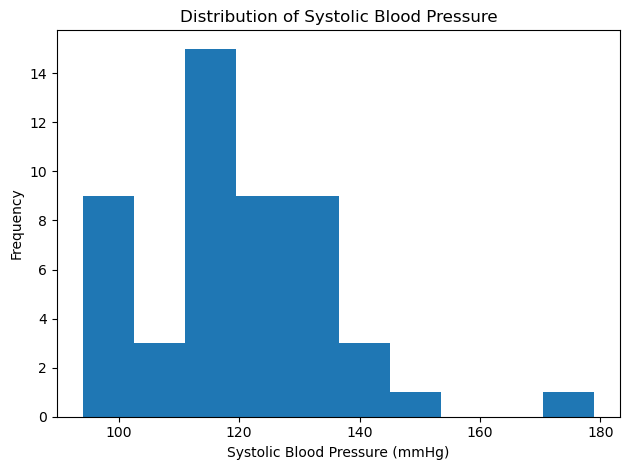

In [148]:
fig, ax = plt.subplots()

ax.hist(
    df["Systolic (mmHg)"].dropna(),
    bins=10
)

ax.set_title("Distribution of Systolic Blood Pressure")
ax.set_xlabel("Systolic Blood Pressure (mmHg)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

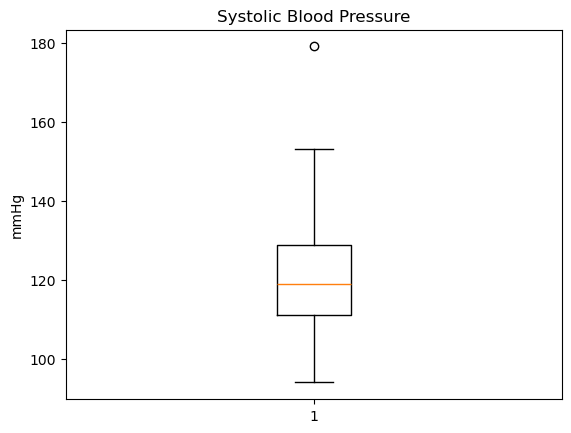

In [149]:
fig, ax = plt.subplots()

ax.boxplot(df["Systolic (mmHg)"].dropna())

ax.set_title("Systolic Blood Pressure")
ax.set_ylabel("mmHg")

plt.show()

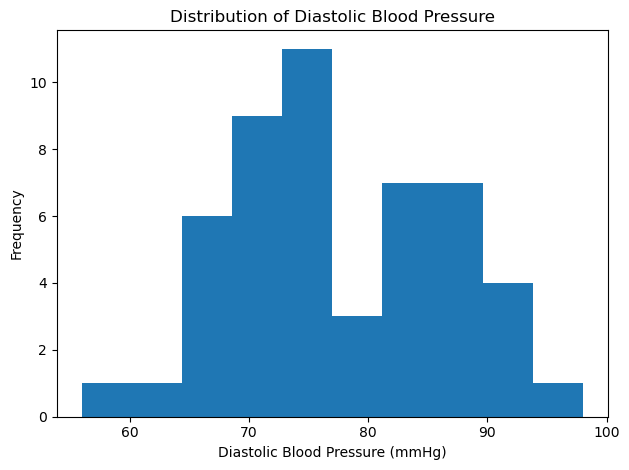

In [150]:
fig, ax = plt.subplots()

ax.hist(
    df["Diastolic (mmHg)"].dropna(),
    bins=10
)

ax.set_title("Distribution of Diastolic Blood Pressure")
ax.set_xlabel("Diastolic Blood Pressure (mmHg)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

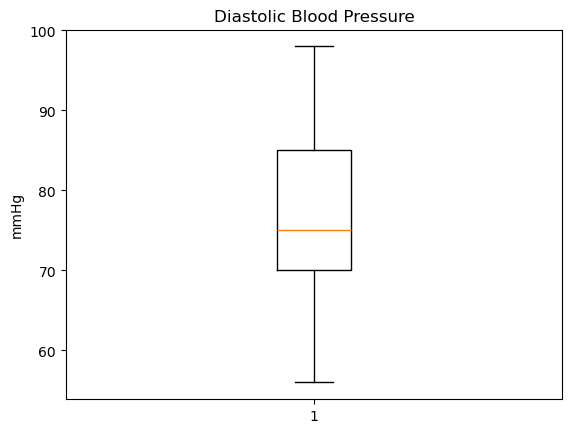

In [151]:
fig, ax = plt.subplots()

ax.boxplot(df["Diastolic (mmHg)"].dropna())

ax.set_title("Diastolic Blood Pressure")
ax.set_ylabel("mmHg")

plt.show()

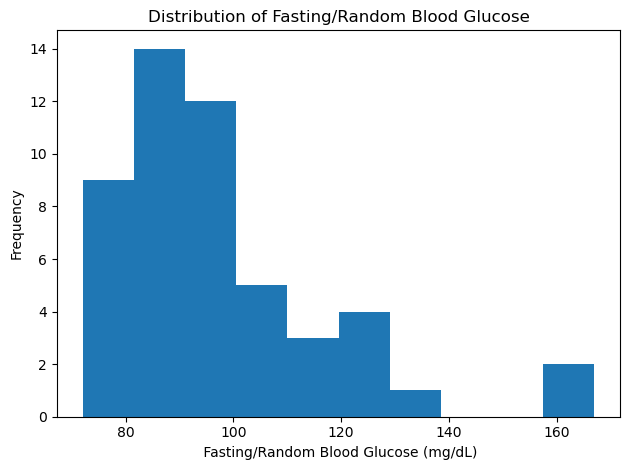

In [152]:
fig, ax = plt.subplots()

ax.hist(
    df["FBS/RBS (mg/dL)"].dropna(),
    bins=10
)

ax.set_title("Distribution of Fasting/Random Blood Glucose")
ax.set_xlabel(" Fasting/Random Blood Glucose (mg/dL)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

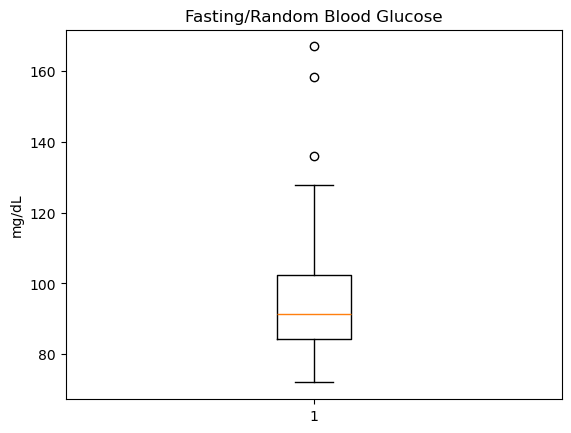

In [153]:
fig, ax = plt.subplots()

ax.boxplot(df["FBS/RBS (mg/dL)"].dropna())

ax.set_title("Fasting/Random Blood Glucose")
ax.set_ylabel("mg/dL")

plt.show()

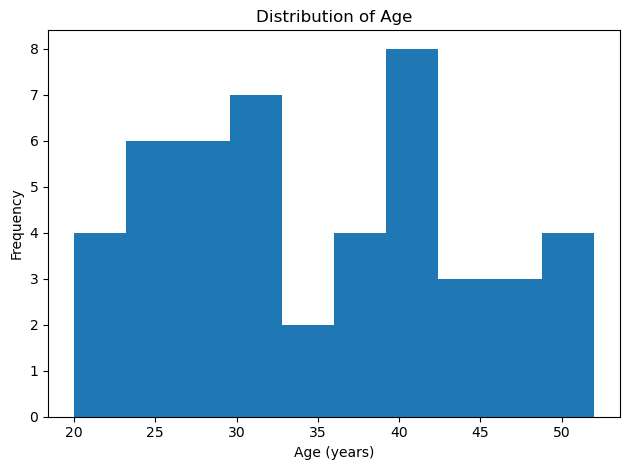

In [154]:
fig, ax = plt.subplots()

ax.hist(
    age_numeric.dropna(),
    bins=10
)

ax.set_title("Distribution of Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

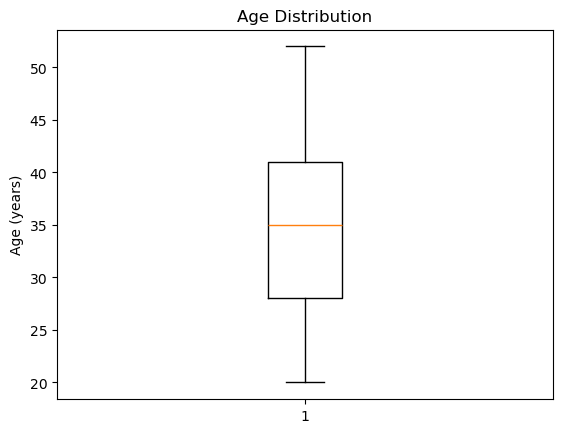

In [155]:
fig, ax = plt.subplots()

ax.boxplot(age_numeric.dropna())

ax.set_title("Age Distribution")
ax.set_ylabel("Age (years)")

plt.show()

In [156]:
df["Sex"].value_counts()

Sex
F    29
M    21
Name: count, dtype: int64

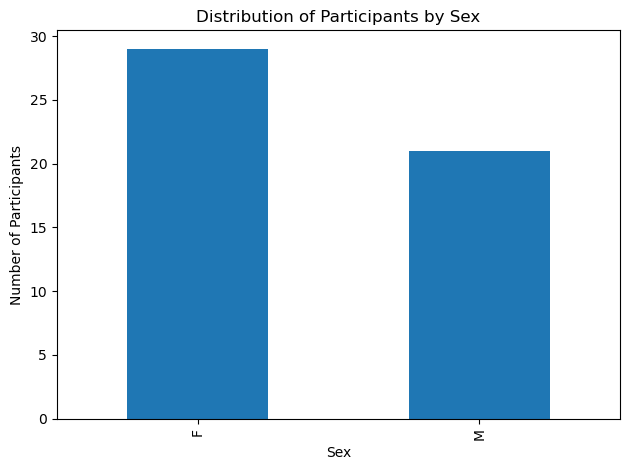

In [157]:
fig, ax = plt.subplots()

df["Sex"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribution of Participants by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Number of Participants")

plt.tight_layout()
plt.show()

In [158]:
df["Location"].value_counts()

Location
Echolab        30
DDPA Estate    16
Lifestream      4
Name: count, dtype: int64

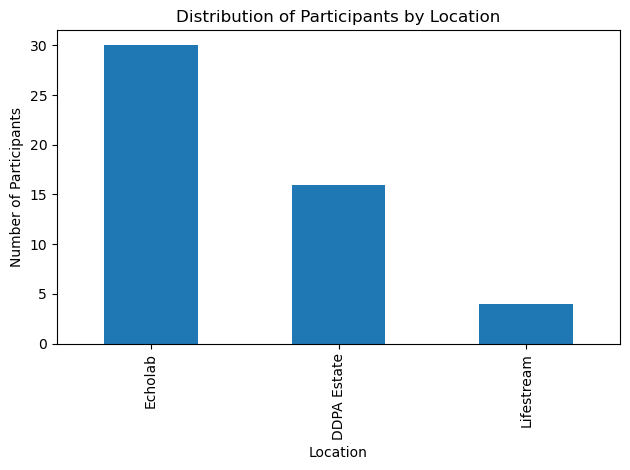

In [159]:
fig, ax = plt.subplots()

df["Location"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribution of Participants by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Number of Participants")

plt.tight_layout()
plt.show()

## Sub-question 2 —Distribution

**Question**

How are the major health measurements distributed?

**Answer**

The distribution of the major health measurements was examined using descriptive statistics and visualizations. The analysis considered systolic blood pressure, diastolic blood pressure, and random blood glucose.

Descriptive statistics were used to examine the centre and spread of the measurements, including the mean, median, standard deviation, minimum, maximum, first quartile (Q1), third quartile (Q3), and interquartile range (IQR).

Histograms and boxplots were also used to visually examine the distributions, identify the overall spread of the observations, assess possible skewness, and identify unusual or extreme observations.

The results showed that the measurements varied across participants, with some observations occurring substantially higher or lower than the central portion of their respective distributions. These unusual observations were not automatically treated as errors and were considered within the context of the data-quality assessment.

Therefore, **Sub-question 2 has been addressed:** the analysis describes the distribution, centre, spread, and notable observations of the major health measurements in the dataset.

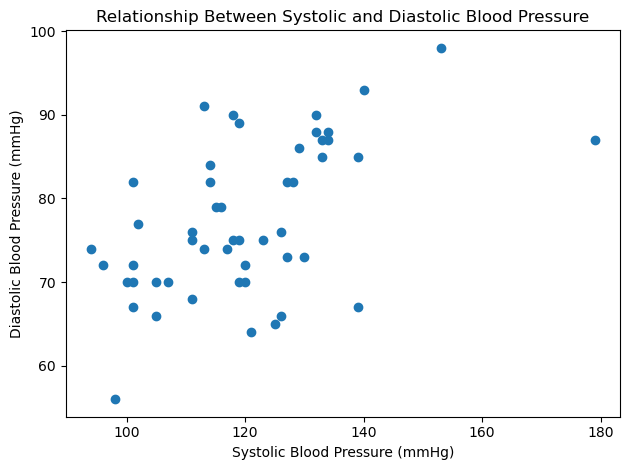

In [160]:
fig, ax = plt.subplots()

ax.scatter(
    df["Systolic (mmHg)"],
    df["Diastolic (mmHg)"]
)

ax.set_title("Relationship Between Systolic and Diastolic Blood Pressure")
ax.set_xlabel("Systolic Blood Pressure (mmHg)")
ax.set_ylabel("Diastolic Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

In [161]:
df[["Systolic (mmHg)", "Diastolic (mmHg)"]].corr()

,Systolic (mmHg),Diastolic (mmHg)
Systolic (mmHg),1.00000,0.53496
Diastolic (mmHg),0.53496,1.00000


In [162]:
df["Systolic (mmHg)"].corr(
    df["Diastolic (mmHg)"],
    method="spearman"
)

np.float64(0.48584731075120025)

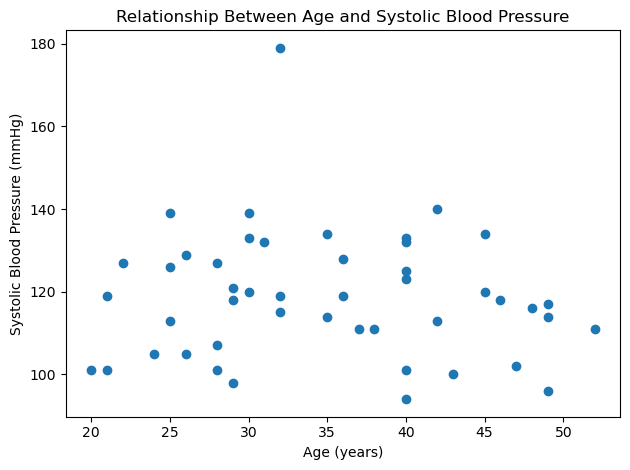

In [163]:
fig, ax = plt.subplots()

ax.scatter(
    df["age_numeric"],
    df["Systolic (mmHg)"]
)

ax.set_title("Relationship Between Age and Systolic Blood Pressure")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Systolic Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

In [187]:
df[["age_numeric", "Systolic (mmHg)"]].corr()

,age_numeric,Systolic (mmHg)
age_numeric,1.000000,-0.077528
Systolic (mmHg),-0.077528,1.000000


In [165]:
df["age_numeric"].corr(
    df["Systolic (mmHg)"],
    method="spearman"
)

np.float64(-0.0573930009201352)

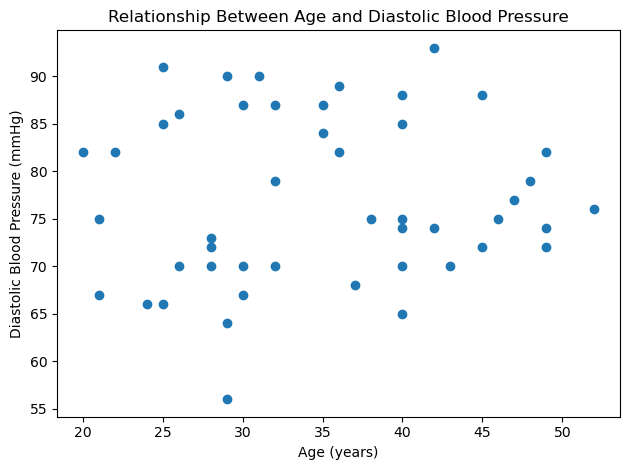

In [166]:
fig, ax = plt.subplots()

ax.scatter(
    df["age_numeric"],
    df["Diastolic (mmHg)"]
)

ax.set_title("Relationship Between Age and Diastolic Blood Pressure")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Diastolic Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

In [188]:
df[["age_numeric", "Diastolic (mmHg)"]].corr()

,age_numeric,Diastolic (mmHg)
age_numeric,1.00000,0.06595
Diastolic (mmHg),0.06595,1.00000


In [168]:
df["age_numeric"].corr(
    df["Diastolic (mmHg)"],
    method="spearman"
)

np.float64(0.11032101069435633)

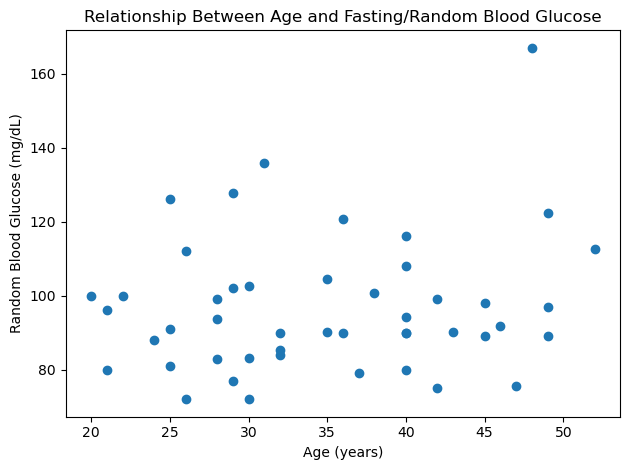

In [169]:
fig, ax = plt.subplots()

ax.scatter(
    age_numeric,
    df["FBS/RBS (mg/dL)"]
)

ax.set_title("Relationship Between Age and Fasting/Random Blood Glucose")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Random Blood Glucose (mg/dL)")

plt.tight_layout()
plt.show()

In [170]:
df["age_numeric"] = pd.to_numeric(df["Age"], errors="coerce")

In [171]:
df[["age_numeric", "FBS/RBS (mg/dL)"]].corr()

,age_numeric,FBS/RBS (mg/dL)
age_numeric,1.000000,0.163057
FBS/RBS (mg/dL),0.163057,1.000000


In [173]:
df["age_numeric"].corr(
    df["FBS/RBS (mg/dL)"],
    method="spearman"
)

np.float64(0.08789882816119939)

In [181]:
numeric_columns = [
    "age_numeric",
    "Systolic (mmHg)",
    "Diastolic (mmHg)",
    "FBS/RBS (mg/dL)"
]

In [182]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,age_numeric,Systolic (mmHg),Diastolic (mmHg),FBS/RBS (mg/dL)
age_numeric,1.000000,-0.077528,0.065950,0.163057
Systolic (mmHg),-0.077528,1.000000,0.534960,-0.057801
Diastolic (mmHg),0.065950,0.534960,1.000000,0.130179
FBS/RBS (mg/dL),0.163057,-0.057801,0.130179,1.000000


## Sub-question 4 — Relationships

**Question**

Are variables such as age, blood pressure, and glucose associated with one another?

**Answer**

The analysis examines relationships between age and the major health measurements, as well as the relationship between the two components of blood pressure.

Specifically, the analysis examines:

- age and systolic blood pressure
- age and diastolic blood pressure
- age and random blood glucose
- systolic and diastolic blood pressure

Scatter plots are used to visually examine these relationships, while correlation is used to describe the direction and strength of association between the numerical variables.

The results describe associations observed within the screened participants and do not establish causation.

Therefore, **Sub-question 4 has been addressed:** the analysis provides evidence about the observed relationships between age, blood pressure, and random blood glucose in the dataset.

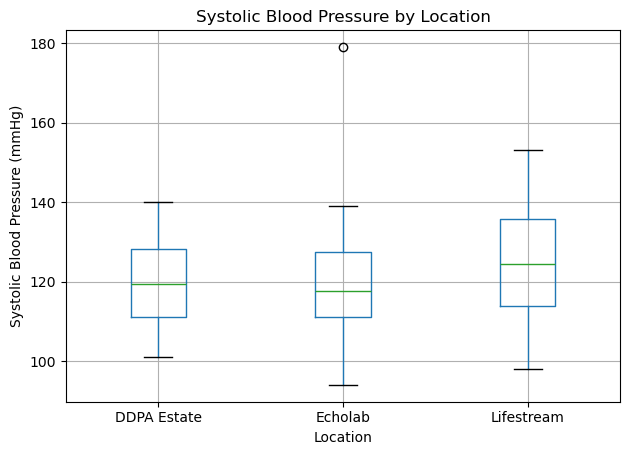

In [174]:
fig, ax = plt.subplots()

df.boxplot(
    column="Systolic (mmHg)",
    by="Location",
    ax=ax
)

ax.set_title("Systolic Blood Pressure by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Systolic Blood Pressure (mmHg)")

plt.suptitle("")

plt.tight_layout()
plt.show()

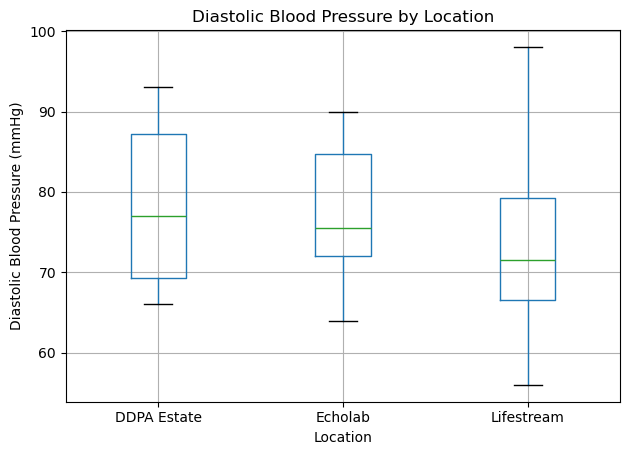

In [175]:
fig, ax = plt.subplots()

df.boxplot(
    column="Diastolic (mmHg)",
    by="Location",
    ax=ax
)

ax.set_title("Diastolic Blood Pressure by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Diastolic Blood Pressure (mmHg)")

plt.suptitle("")

plt.tight_layout()
plt.show()

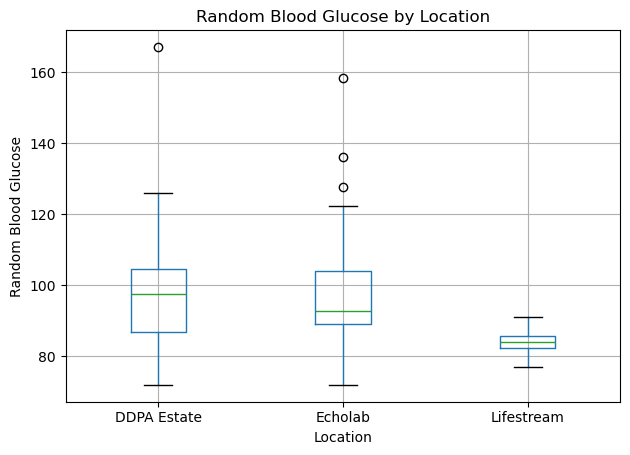

In [190]:
fig, ax = plt.subplots()

df.boxplot(
    column="FBS/RBS (mg/dL)",
    by="Location",
    ax=ax
)

ax.set_title("Random Blood Glucose by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Random Blood Glucose")

plt.suptitle("")

plt.tight_layout()
plt.show()

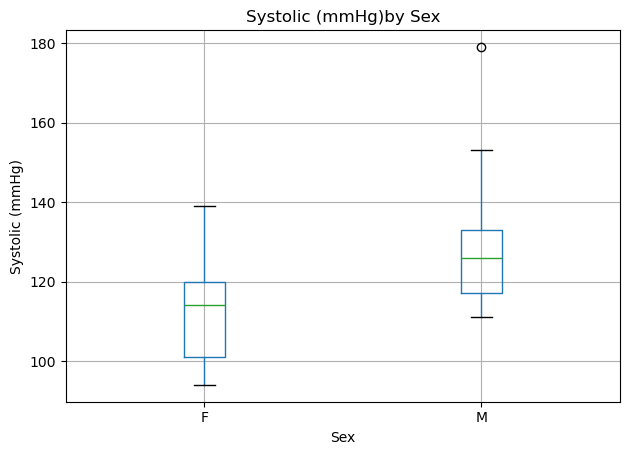

In [192]:
fig, ax = plt.subplots()

df.boxplot(
    column="Systolic (mmHg)",
    by="Sex",
    ax=ax
)

ax.set_title("Systolic (mmHg)by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Systolic (mmHg)")

plt.suptitle("")

plt.tight_layout()
plt.show()

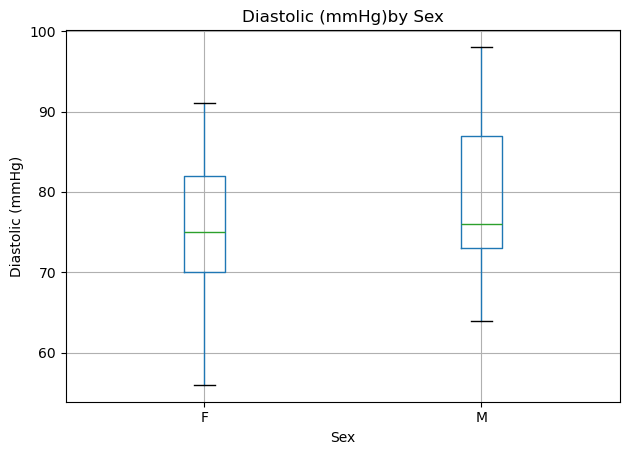

In [191]:
fig, ax = plt.subplots()

df.boxplot(
    column="Diastolic (mmHg)",
    by="Sex",
    ax=ax
)

ax.set_title("Diastolic (mmHg)by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Diastolic (mmHg)")

plt.suptitle("")

plt.tight_layout()
plt.show()

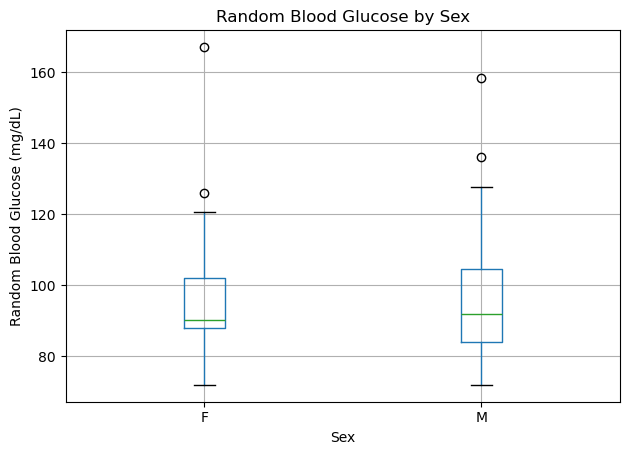

In [176]:
fig, ax = plt.subplots()

df.boxplot(
    column="FBS/RBS (mg/dL)",
    by="Sex",
    ax=ax
)

ax.set_title("Random Blood Glucose by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Random Blood Glucose (mg/dL)")

plt.suptitle("")

plt.tight_layout()
plt.show()

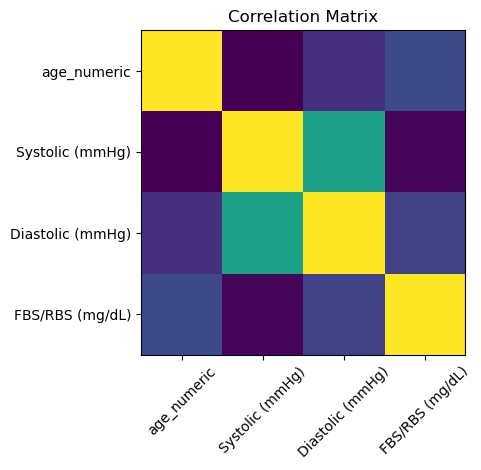

In [183]:
fig, ax = plt.subplots()

im = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))

ax.set_xticklabels(numeric_columns, rotation=45)
ax.set_yticklabels(numeric_columns)

ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [184]:
location_summary = df.groupby("Location").agg(
    count=("Location", "count"),
    systolic_mean=("Systolic (mmHg)", "mean"),
    systolic_median=("Systolic (mmHg)", "median"),
    systolic_std=("Systolic (mmHg)","std"),
    diastolic_mean=("Diastolic (mmHg)", "mean"),
    diastolic_median=("Diastolic (mmHg)", "median"),
    diastolic_std=("Diastolic (mmHg)","std"),
    rbs_mean=("FBS/RBS (mg/dL)", "mean"),
    rbs_median=("FBS/RBS (mg/dL)", "median"),
    rbs_std=("FBS/RBS (mg/dL)", "std")
)

location_summary

,count,systolic_mean,systolic_median,systolic_std,diastolic_mean,diastolic_median,diastolic_std,rbs_mean,rbs_median,rbs_std
Location,,,,,,,,,,
DDPA Estate,16,120.125,119.5,12.779541,78.000000,77.0,9.715966,99.762500,97.6,23.133724
Echolab,30,118.900,117.5,16.605670,77.366667,75.5,7.480934,98.406667,92.7,19.075909
Lifestream,4,125.000,124.5,22.905603,74.250000,71.5,17.480942,84.000000,84.0,5.715476


## Sub-question 3 — Group Differences

**Question**

Do health measurements differ descriptively across relevant demographic or geographic groups?

**Answer**

The analysis compares blood pressure and random blood glucose measurements across the available demographic and geographic groups in the dataset.

For geographic differences, systolic blood pressure, diastolic blood pressure, and Fasting/random blood glucose are compared across screening locations using grouped descriptive statistics and boxplots.

For demographic differences,  systolic blood pressure, diastolic blood pressure ,random blood glucose is compared across sex groups using grouped descriptive statistics and a boxplot.

These comparisons describe the observed differences between groups within the screened participants. They do not establish statistical significance or causation.

Therefore, **Sub-question 3 has been addressed:** the analysis provides a descriptive assessment of whether the measured health outcomes differ across the relevant groups represented in the dataset.

In [198]:
df["pulse_pressure"] = (
    df["Systolic (mmHg)"] -
    df["Diastolic (mmHg)"]
)

In [199]:
df["pulse_pressure"].describe()

count    50.000000
mean     42.460000
std      13.320553
min      19.000000
25%      34.250000
50%      43.000000
75%      48.000000
max      92.000000
Name: pulse_pressure, dtype: float64

In [200]:
# Sort, reset, and set 'S/N' as the index
df = df.sort_values("S/N").set_index("S/N")

# Select and display your columns
df[["Systolic (mmHg)", "Diastolic (mmHg)", "pulse_pressure"]]

,Systolic (mmHg),Diastolic (mmHg),pulse_pressure
S/N,,,
1,132,90,42
2,133,85,48
3,96,72,24
4,114,82,32
5,111,68,43
6,139,85,54
7,179,87,92
8,134,87,47
9,114,84,30


### Statistical Thinking

Descriptive statistics and visualizations describe patterns observed in the sample, but they do not by themselves establish whether those patterns would be expected in a larger population.

Interpretation of health data requires consideration of sampling, uncertainty, sample size, and the distinction between observed associations and causal relationships.

These concepts will be developed further in later projects.

## Sub-question 5— Interpretation

**Question**

What can reasonably be concluded from the observed patterns, and what remains uncertain?

**Answer**

The findings from the descriptive, univariate, and bivariate analyses are brought together to identify the main patterns observed in the screening data.

The analysis can describe the distribution of the measured health variables, differences observed across participant groups, and associations between selected numerical variables.

However, the findings should be interpreted within the limitations of the dataset. The sample represents participants screened during a community health initiative and is not necessarily representative of the wider population. The measurements also represent observations from the screening period and should not be interpreted as diagnostic confirmation of a health condition.

Therefore, **Sub-question 6 has been addressed:** the analysis identifies observable patterns and relationships in the dataset while clearly distinguishing what can be concluded from what remains uncertain.

## Limitations

This analysis has several limitations.

- The sample size is relatively small.
- Participants were obtained through a community screening activity rather than probability sampling, so the sample may not represent the wider population.
- Blood pressure and random blood glucose measurements can be influenced by measurement conditions, timing, and other factors.
- The data are observational and therefore cannot establish causal relationships.
- The screening dataset represents the participants included in this project and should not be interpreted as population-level prevalence estimates.
- Some participants had repeated measurements, which means observations may not always be statistically independent.
- The available variables do not capture every factor that may influence blood pressure or blood glucose.